## Compare results applying ECOD to the retransplantation plate with coSMicQC

In [ ]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
from cytodataframe import CytoDataFrame
from ipython.display import display
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_density,
    geom_point,
    geom_vline,
    ggplot,
    guide_legend,
    guides,
    labs,
    scale_color_manual,
    scale_fill_manual,
    theme,
    theme_bw,
)
from plotnine.options import set_option
from pyod.models.ecod import ECOD
from skimage import exposure


In [ ]:
# Set correlation cache directory to avoid rerunning every time
cache_dir = Path("corr_cache")
cache_dir.mkdir(exist_ok=True)


## Helper functions

In [ ]:
# -----------------------------
# Mild histogram equalization
# -----------------------------
def mild_histogram_equalization(image: np.ndarray, sample: np.ndarray) -> np.ndarray:
    """
    Apply mild histogram equalization to an image.

    Parameters:
    image (np.ndarray): The input image.
    sample (np.ndarray): The sample image for reference.

    Returns:
    np.ndarray: The equalized image.
    """
    return exposure.equalize_adapthist(
        image,
        clip_limit=0.01
    )

# -----------------------------
# Cohen's d
# -----------------------------
def compute_cohens_d(x: np.ndarray, y: np.ndarray) -> float:
    """
    Calculate Cohen's d effect size between two distributions.

    Args:
        x (np.ndarray):
            First distribution of values.
        y (np.ndarray):
            Second distribution of values.

    Returns:
        float:
            Cohen's d effect size.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    nx: int = len(x)
    ny: int = len(y)

    pooled_sd: float = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2)
    )

    return float((np.mean(x) - np.mean(y)) / pooled_sd)


def prep_pairwise(corr_matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Prepare the upper triangular indices and corresponding correlation values
    from a correlation matrix for further analysis.

    Args:
        corr_matrix (np.ndarray):
            A square correlation matrix.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]:
            - iu: Row indices of the upper triangular part of the matrix.
            - ju: Column indices of the upper triangular part of the matrix.
            - corr_matrix[iu, ju]: Corresponding correlation values.
    """
    n = corr_matrix.shape[0]
    iu, ju = np.triu_indices(n, k=1)
    return iu, ju, corr_matrix[iu, ju]


def cohens_d_from_labels(
    iu: np.ndarray, ju: np.ndarray, corr_vals: np.ndarray, is_fail: np.ndarray
) -> float:
    fail_fail_mask = is_fail[iu] & is_fail[ju]
    pass_pass_mask = (~is_fail[iu]) & (~is_fail[ju])
    return compute_cohens_d(corr_vals[fail_fail_mask], corr_vals[pass_pass_mask])


# -----------------------------
# Fast vectorized permutation machinery between methods
# -----------------------------
def prep_corr_stats(
    corr_matrix: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Precompute the matrices needed for batched Cohen's d via quadratic forms.
    float32 for speed/memory; negligible precision loss for this purpose.

    Args:
        corr_matrix (np.ndarray):
            A square correlation matrix.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
            - C: The correlation matrix as float32.
            - C2: The element-wise square of the correlation matrix as float32.
            - C_rowsum: The sum of each row in the correlation matrix.
            - C2_rowsum: The sum of each row in the squared correlation matrix.
    """
    C = corr_matrix.astype(np.float32)
    C2 = (C**2).astype(np.float32)
    C_rowsum = C.sum(axis=1)
    C2_rowsum = C2.sum(axis=1)
    return C, C2, C_rowsum, C2_rowsum


def sample_label_matrix(
    rng: np.random.Generator, n_cells: int, n_fail: int, n_permutations: int
) -> np.ndarray:
    """
    Vectorized generation of `n_permutations` random binary label vectors,
    each with exactly `n_fail` ones out of `n_cells`, with no Python loop.

    Args:
        rng (np.random.Generator): A NumPy random number generator instance.
        n_cells (int): Total number of cells.
        n_fail (int): Number of failing cells (ones) in each permutation.
        n_permutations (int): Number of permutations to generate.

    Returns:
        np.ndarray: A binary matrix of shape (n_permutations, n_cells),
                    where each row is a random permutation of labels.
    """
    R = rng.random((n_permutations, n_cells)).astype(np.float32)
    thresh = np.partition(R, n_fail - 1, axis=1)[:, n_fail - 1]
    return (thresh[:, None] >= R).astype(np.float32)


def batch_cohens_d(
    C: np.ndarray,
    C2: np.ndarray,
    C_rowsum: np.ndarray,
    C2_rowsum: np.ndarray,
    V: np.ndarray,
) -> np.ndarray:
    """
    V: (P, n_cells) binary label matrix, one row per permutation (1 = fail).
    Returns an array of P Cohen's d values (fail-fail vs pass-pass), computed
    for all P permutations simultaneously via matrix multiplication.

    Args:
        C (np.ndarray): Correlation matrix.
        C2 (np.ndarray): Element-wise square of the correlation matrix.
        C_rowsum (np.ndarray): Row sums of the correlation matrix.
        C2_rowsum (np.ndarray): Row sums of the squared correlation matrix.
        V (np.ndarray): Binary label matrix of shape (P, n_cells).

    Returns:
        np.ndarray: Array of Cohen's d values for each permutation.
    """
    n = C.shape[0]
    nk = V.sum(axis=1)  # fail count per permutation, shape (P,)
    mk = n - nk  # pass count per permutation

    CV = C @ V.T  # (n, P) — the expensive step, done once for all P
    C2V = C2 @ V.T  # (n, P)

    Vt = V.T
    sum_C_vv = (Vt * CV).sum(axis=0)  # v^T C v  for each permutation
    sum_C2_vv = (Vt * C2V).sum(axis=0)  # v^T C2 v for each permutation

    # Pass-group quantities reuse the same matmul output (W = 1 - V)
    CW = C_rowsum[:, None] - CV
    C2W = C2_rowsum[:, None] - C2V
    Wt = 1.0 - Vt
    sum_C_ww = (Wt * CW).sum(axis=0)
    sum_C2_ww = (Wt * C2W).sum(axis=0)

    count_ff = nk * (nk - 1) / 2
    count_pp = mk * (mk - 1) / 2

    sum_ff = (sum_C_vv - nk) / 2
    sum_ff_sq = (sum_C2_vv - nk) / 2
    sum_pp = (sum_C_ww - mk) / 2
    sum_pp_sq = (sum_C2_ww - mk) / 2

    mean_ff = sum_ff / count_ff
    mean_pp = sum_pp / count_pp

    var_ff = (sum_ff_sq - sum_ff**2 / count_ff) / (count_ff - 1)
    var_pp = (sum_pp_sq - sum_pp**2 / count_pp) / (count_pp - 1)

    pooled_sd = np.sqrt(
        ((count_ff - 1) * var_ff + (count_pp - 1) * var_pp) / (count_ff + count_pp - 2)
    )
    return (mean_ff - mean_pp) / pooled_sd


def permutation_test_within_method_fast(
    stats: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
    is_fail: np.ndarray,
    n_permutations: int = 5000,
    seed: int = 0,
    batch_size: int = 1000,
) -> dict:
    """
    Perform a permutation test to assess the significance of the observed Cohen's d
    effect size between failing and passing cells within a single method.

    Args:
        stats (tuple): Precomputed correlation statistics (C, C2, C_rowsum, C2_rowsum).
        is_fail (np.ndarray): Binary array indicating failing cells and passing cells.
        n_permutations (int): Number of permutations to perform.
        seed (int): Random seed for reproducibility.
        batch_size (int): Number of permutations to compute in each batch.

    Returns:
        dict: A dictionary containing the observed Cohen's d, the null distribution of
              Cohen's d from permutations, and the p-value.
    """
    C, C2, C_rowsum, C2_rowsum = stats
    iu, ju, corr_vals = prep_pairwise(
        C
    )  # C already float32 here, fine for the single observed calc
    d_observed = cohens_d_from_labels(iu, ju, corr_vals, is_fail)

    rng = np.random.default_rng(seed)
    n_cells = len(is_fail)
    n_fail = int(is_fail.sum())

    null_d = np.empty(n_permutations)
    done = 0
    while done < n_permutations:
        cur = min(batch_size, n_permutations - done)
        V = sample_label_matrix(rng, n_cells, n_fail, cur)
        null_d[done : done + cur] = batch_cohens_d(C, C2, C_rowsum, C2_rowsum, V)
        done += cur

    p_value = (
        (np.sum(null_d >= d_observed) + 1) / (len(null_d) + 1)
        if d_observed >= 0
        else (np.sum(null_d <= d_observed) + 1) / (len(null_d) + 1)
    )
    return {"d_observed": d_observed, "null_distribution": null_d, "p_value": p_value}


def permutation_test_between_methods_fast(  # noqa: PLR0913
    stats: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
    is_fail_a: np.ndarray,
    is_fail_b: np.ndarray,
    n_permutations: int = 5000,
    seed: int = 0,
    batch_size: int = 1000,
) -> dict:
    """
    Perform a permutation test to assess the significance of the difference in Cohen's d
    effect sizes between two methods.

    Args:
        stats (tuple): Precomputed correlation statistics (C, C2, C_rowsum, C2_rowsum).
        is_fail_a (np.ndarray): Binary array indicating failing cells for method A.
        is_fail_b (np.ndarray): Binary array indicating failing cells for method B.
        n_permutations (int): Number of permutations to perform.
        seed (int): Random seed for reproducibility.
        batch_size (int): Number of permutations to compute in each batch.

    Returns:
        dict: A dictionary containing the observed Cohen's d for each method, the null
            distribution of the difference in Cohen's d from permutations, and p-value.
    """
    C, C2, C_rowsum, C2_rowsum = stats
    iu, ju, corr_vals = prep_pairwise(C)
    d_a_observed = cohens_d_from_labels(iu, ju, corr_vals, is_fail_a)
    d_b_observed = cohens_d_from_labels(iu, ju, corr_vals, is_fail_b)
    diff_observed = d_a_observed - d_b_observed

    rng = np.random.default_rng(seed)
    n_cells = len(is_fail_a)
    n_fail_a = int(is_fail_a.sum())
    n_fail_b = int(is_fail_b.sum())

    null_diff = np.empty(n_permutations)
    done = 0
    while done < n_permutations:
        cur = min(batch_size, n_permutations - done)
        V_a = sample_label_matrix(rng, n_cells, n_fail_a, cur)
        V_b = sample_label_matrix(rng, n_cells, n_fail_b, cur)
        d_a = batch_cohens_d(C, C2, C_rowsum, C2_rowsum, V_a)
        d_b = batch_cohens_d(C, C2, C_rowsum, C2_rowsum, V_b)
        null_diff[done : done + cur] = d_a - d_b
        done += cur

    p_value = np.mean(np.abs(null_diff) >= np.abs(diff_observed))
    return {
        "d_a_observed": d_a_observed,
        "d_b_observed": d_b_observed,
        "diff_observed": diff_observed,
        "null_distribution": null_diff,
        "p_value": p_value,
    }

# -----------------------------
# Fast vectorized cross-group Cohen's d
# -----------------------------

def batch_cross_group_cohens_d(  # noqa: PLR0913
    C: np.ndarray,
    C2: np.ndarray,
    C_rowsum: np.ndarray,
    C2_rowsum: np.ndarray,
    V_a: np.ndarray,
    V_b: np.ndarray,
) -> np.ndarray:
    """
    Calculate Cohen's d comparing cross-group correlations between two QC
    methods for many permutations.

    V_a:
        Binary label matrix for method A (1 = failed)

    V_b:
        Binary label matrix for method B (1 = failed)

    Returns:
        Cohen's d comparing:
            method A failed-passed correlations
            vs
            method B failed-passed correlations
    """

    def cross_group_stats(V: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Calculate mean, variance, and count of cross-group correlations
        for a given binary label matrix V (1 = failed, 0 = passed).

        Args:
            V: Binary label matrix (shape: n_permutations x n_cells)

        Returns:
            mean_cross: Mean of cross-group correlations
            var_cross: Variance of cross-group correlations
            count_cross: Count of cross-group correlations
        """
        # V: (P, n_cells)
        Vt = V.T
        Wt = 1.0 - Vt

        n_fail = V.sum(axis=1)
        n_pass = V.shape[1] - n_fail

        # Matrix multiplication
        CV = C @ Vt
        C2V = C2 @ Vt

        # Passed side
        CW = C_rowsum[:, None] - CV
        C2W = C2_rowsum[:, None] - C2V

        # failed -> passed correlations
        sum_cross = (Vt * CW).sum(axis=0)
        sum_cross_sq = (Vt * C2W).sum(axis=0)

        count_cross = n_fail * n_pass

        mean_cross = sum_cross / count_cross

        var_cross = (
            sum_cross_sq - (sum_cross**2 / count_cross)
        ) / (count_cross - 1)

        return mean_cross, var_cross, count_cross

    mean_a, var_a, count_a = cross_group_stats(V_a)
    mean_b, var_b, count_b = cross_group_stats(V_b)

    pooled_sd = np.sqrt(
        (
            (count_a - 1) * var_a
            +
            (count_b - 1) * var_b
        )
        /
        (count_a + count_b - 2)
    )

    return (mean_a - mean_b) / pooled_sd

def permutation_test_cross_group_between_methods_fast(  # noqa: PLR0913
    stats: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
    is_fail_a: np.ndarray,
    is_fail_b: np.ndarray,
    n_permutations: int = 5000,
    seed: int = 0,
    batch_size: int = 1000,
) -> dict:
    """
    Permutation test comparing cross-group correlation distributions
    between two QC methods.

    Tests whether the difference between:
        Method A failed-passed correlations

    and:

        Method B failed-passed correlations

    is larger than expected by random assignment.
    """

    C, C2, C_rowsum, C2_rowsum = stats

    # Observed statistic
    V_a_obs = is_fail_a[np.newaxis, :].astype(np.float32)
    V_b_obs = is_fail_b[np.newaxis, :].astype(np.float32)

    d_observed = batch_cross_group_cohens_d(
        C,
        C2,
        C_rowsum,
        C2_rowsum,
        V_a_obs,
        V_b_obs,
    )[0]

    rng = np.random.default_rng(seed)

    n_cells = len(is_fail_a)

    n_fail_a = int(is_fail_a.sum())
    n_fail_b = int(is_fail_b.sum())

    null_d = np.empty(n_permutations)

    done = 0

    while done < n_permutations:

        cur = min(batch_size, n_permutations - done)

        V_a = sample_label_matrix(
            rng,
            n_cells,
            n_fail_a,
            cur,
        )

        V_b = sample_label_matrix(
            rng,
            n_cells,
            n_fail_b,
            cur,
        )

        null_d[done:done + cur] = batch_cross_group_cohens_d(
            C,
            C2,
            C_rowsum,
            C2_rowsum,
            V_a,
            V_b,
        )

        done += cur

    # two-sided permutation p-value
    p_value = (
        np.sum(np.abs(null_d) >= np.abs(d_observed)) + 1
    ) / (len(null_d) + 1)

    return {
        "d_observed": d_observed,
        "null_distribution": null_d,
        "p_value": p_value,
    }

# -----------------------------
# PACK FUNCTION
# -----------------------------
def pack(
    values: np.ndarray,
    method: str,
    comparison: str,
    iteration: int,
) -> pd.DataFrame:
    """
    Convert correlation values into long-format dataframe.

    Args:
        values (np.ndarray):
            Correlation values (pairwise or cross-group).
        method (str):
            QC method name ("ECOD" or "coSMicQC").
        comparison (str):
            Comparison type:
                - "Failed vs Failed"
                - "Passed vs Passed"
                - "Passed vs Failed"
        iteration (int):
            Bootstrap iteration index.

    Returns:
        pd.DataFrame:
            Long-format dataframe for plotting.
    """
    return pd.DataFrame(
        {
            "iteration": iteration,
            "correlation": values,
            "method": method,
            "comparison": comparison,
        }
    )


def classify_comparison(group: str) -> str:
    """Update the comparison groups for plotting

    Args:
        group (str): Original comparison group label

    Returns:
        str: New comparison label for plotting
    """
    if "Passed" in group and "Failed" in group:
        return "Passed vs failed cells"
    elif "Passed" in group and "Failed" not in group:
        return "Passed cells only"
    else:
        return "Failed cells only"


In [ ]:
# Set figure directory
figure_dir = Path("./figures")
figure_dir.mkdir(exist_ok=True)

# Load dataframe
no_QC_df = pd.read_parquet(
    Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/converted_profiles/localhost230405150001_converted.parquet"
    )
)

# Build Hoechst filenames (d0)
no_QC_df["Image_FileName_Hoechst"] = (
    no_QC_df["Image_Metadata_Plate"]
    + "_"
    + no_QC_df["Image_Metadata_Well"]
    + no_QC_df["Image_Metadata_Site"]
    + "d0_illumcorrect.tiff"
)

# Build Actin filenames (d4)
no_QC_df["Image_FileName_Actin"] = (
    no_QC_df["Image_Metadata_Plate"]
    + "_"
    + no_QC_df["Image_Metadata_Well"]
    + no_QC_df["Image_Metadata_Site"]
    + "d4_illumcorrect.tiff"
)

print(no_QC_df.shape)
no_QC_df.head()


(25859, 2018)


,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,Metadata_Image_Count_Cells,Metadata_ImageNumber,Image_Metadata_Plate,Image_Metadata_Site,Image_Metadata_Well,Metadata_Cells_Number_Object_Number,...,Nuclei_Texture_Variance_Mitochondria_3_00_256,Nuclei_Texture_Variance_Mitochondria_3_01_256,Nuclei_Texture_Variance_Mitochondria_3_02_256,Nuclei_Texture_Variance_Mitochondria_3_03_256,Nuclei_Texture_Variance_PM_3_00_256,Nuclei_Texture_Variance_PM_3_01_256,Nuclei_Texture_Variance_PM_3_02_256,Nuclei_Texture_Variance_PM_3_03_256,Image_FileName_Hoechst,Image_FileName_Actin
0,221.046761,137.115493,246.602800,109.285755,40,1,localhost230405150001,f00,B02,1,...,0.529422,0.478064,0.489459,0.475133,2.703146,2.664110,2.650578,2.664691,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff
1,690.596142,183.067828,716.170091,177.132195,40,1,localhost230405150001,f00,B02,2,...,46.883295,50.496897,42.311975,39.973584,4.376776,4.567953,4.220630,4.058367,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff
2,626.561490,206.923698,623.943740,199.906440,40,1,localhost230405150001,f00,B02,3,...,0.970588,0.952145,0.950279,0.908622,2.568485,2.578927,2.556851,2.541355,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff
3,559.448583,220.688160,528.646623,196.955552,40,1,localhost230405150001,f00,B02,4,...,2.511639,2.456358,2.509622,2.547159,3.866945,4.011720,4.004412,3.866034,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff
4,909.019946,247.694340,897.965996,253.621836,40,1,localhost230405150001,f00,B02,5,...,5.823674,6.553608,6.620230,5.453092,2.029099,2.044566,2.038007,2.058557,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff


In [ ]:
# Identify columns to drop (metadata only)
drop_cols = no_QC_df.columns[
    no_QC_df.columns.str.startswith("Image_Metadata")
    | no_QC_df.columns.str.startswith("Metadata_")
    | no_QC_df.columns.str.startswith("Image_FileName")
]

# Feature matrix
X = no_QC_df.drop(columns=drop_cols)

# Drop columns with ANY NaNs in features (required for ECOD to work)
X_clean = X.loc[:, ~X.isna().any()]

# Fit ECOD
ecod = ECOD(contamination=0.193, n_jobs=-1)
ecod.fit(X_clean)

# Predict labels
ecod_labels = ecod.labels_

# Store results back ONLY for valid rows
no_QC_df["ECOD_flag"] = np.nan
no_QC_df.loc[X_clean.index, "ECOD_flag"] = ecod_labels


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:    3.8s remaining:   26.6s
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:    5.7s finished
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/pyod/models/ecod.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.


In [ ]:
# Assign ECOD labels directly (same row order preserved)
no_QC_df["ECOD_flag"] = ecod.labels_

# Counts
flagged_cells = no_QC_df["ECOD_flag"].sum()
total_cells = len(no_QC_df)
fraction_flagged = flagged_cells / total_cells

print(f"Total cells: {total_cells}")
print(f"Flagged cells (ECOD): {flagged_cells}")
print(f"Fraction flagged: {fraction_flagged:.4f}")


Total cells: 25859
Flagged cells (ECOD): 4991
Fraction flagged: 0.1930


In [ ]:
# Load in dataframe with each cell that passed or failed QC from coSMicQC
cosmicqc_df = pd.read_parquet("../figure_3/umap_embeddings/pre_QC_umap_embeddings.parquet")

print(cosmicqc_df.shape)
cosmicqc_df.head()


(25859, 23)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_Site,Metadata_Treatment_CellType_ID,UMAP0,UMAP1,Metadata_QC_status
0,B,2,9,diseased,rejected,control,221.046761,137.115493,246.602800,109.285755,...,B02,1,1,6,6,f00,DMSO-control diseased,-2.078834,4.570251,passed
1,B,2,9,diseased,rejected,control,690.596142,183.067828,716.170091,177.132195,...,B02,2,2,7,7,f00,DMSO-control diseased,-1.326478,7.692071,passed
2,B,2,9,diseased,rejected,control,626.561490,206.923698,623.943740,199.906440,...,B02,3,3,8,8,f00,DMSO-control diseased,-1.747116,8.019854,passed
3,B,2,9,diseased,rejected,control,559.448583,220.688160,528.646623,196.955552,...,B02,4,4,9,9,f00,DMSO-control diseased,-2.015016,5.848380,passed
4,B,2,9,diseased,rejected,control,909.019946,247.694340,897.965996,253.621836,...,B02,5,5,10,10,f00,DMSO-control diseased,-0.918467,5.391689,passed


In [ ]:
# Filter for rows where ECOD flagged cells as outliers
no_QC_df = no_QC_df.copy()

# Update plate, well, and site metadata to drop Image_ prefix
no_QC_df = no_QC_df.rename(
    columns=lambda c: c.replace("Image_", "") if c.startswith("Image_") else c
)
ECOD_outliers = no_QC_df[no_QC_df["ECOD_flag"] == 1].copy()

# Filter for only rows where cells failed coSMicQC
cosmicqc_df = cosmicqc_df.copy()
cosmic_outliers = cosmicqc_df[cosmicqc_df["Metadata_QC_status"] == "failed"].copy()

key_cols = [
    "Metadata_Plate",
    "Metadata_Well",
    "Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
]

ECOD_outliers["cell_key"] = ECOD_outliers[key_cols].astype(str).agg("_".join, axis=1)
cosmic_outliers["cell_key"] = (
    cosmic_outliers[key_cols].astype(str).agg("_".join, axis=1)
)

# --- SETS FOR COMPARISON ---
ecod_set = set(ECOD_outliers["cell_key"])
cosmic_set = set(cosmic_outliers["cell_key"])

overlap = ecod_set & cosmic_set

print("ECOD outliers:", len(ecod_set))
print("coSMicQC outliers:", len(cosmic_set))
print("Overlap:", len(overlap))
print("ECOD overlap fraction:", len(overlap) / len(ecod_set))
print("coSMicQC overlap fraction:", len(overlap) / len(cosmic_set))


ECOD outliers: 4991
coSMicQC outliers: 4994
Overlap: 2337
ECOD overlap fraction: 0.4682428371067922
coSMicQC overlap fraction: 0.46796155386463756


In [ ]:
# --- normalize column names so key_cols exist in both dfs ---
no_QC_df = no_QC_df.copy()
cosmicqc_df = cosmicqc_df.copy()

no_QC_df.columns = no_QC_df.columns.str.replace("Image_", "", regex=False)
cosmicqc_df.columns = cosmicqc_df.columns.str.replace("Image_", "", regex=False)

# --- key columns (now valid after normalization) ---
key_cols = [
    "Metadata_Plate",
    "Metadata_Well",
    "Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
]

# --- create ECOD side key first ---
no_QC_df["cell_key"] = no_QC_df[key_cols].astype(str).agg("_".join, axis=1)

ecod_lookup = no_QC_df[
    ["cell_key", "ECOD_flag"]
    + [
        c
        for c in no_QC_df.columns
        if "BoundingBox" in c
        or "bounding" in c.lower()
        or "FileName" in c
        or "filename" in c.lower()
    ]
].copy()

# --- cosmicQC side ---
cosmicqc_df["cell_key"] = cosmicqc_df[key_cols].astype(str).agg("_".join, axis=1)

# --- merge ---
cosmicqc_df = cosmicqc_df.merge(ecod_lookup, on="cell_key", how="left")

cosmicqc_df["ECOD_flag"] = cosmicqc_df["ECOD_flag"].fillna(-1)

cosmicqc_df["ECOD_group"] = cosmicqc_df["ECOD_flag"].map(
    {1: "ECOD_outlier", 0: "ECOD_inlier", -1: "ECOD_missing"}
)

print("ECOD outliers:", (cosmicqc_df["ECOD_flag"] == 1).sum())
print("ECOD inliers:", (cosmicqc_df["ECOD_flag"] == 0).sum())
print("ECOD missing:", (cosmicqc_df["ECOD_flag"] == -1).sum())

cosmicqc_df.head()


ECOD outliers: 4991
ECOD inliers: 20868
ECOD missing: 0


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Cells_AreaShape_BoundingBoxMinimum_X,Cells_AreaShape_BoundingBoxMinimum_Y,Nuclei_AreaShape_BoundingBoxArea,Nuclei_AreaShape_BoundingBoxMaximum_X,Nuclei_AreaShape_BoundingBoxMaximum_Y,Nuclei_AreaShape_BoundingBoxMinimum_X,Nuclei_AreaShape_BoundingBoxMinimum_Y,FileName_Hoechst,FileName_Actin,ECOD_group
0,B,2,9,diseased,rejected,control,221.046761,137.115493,246.602800,109.285755,...,109.0,14.0,2310.0,242.0,165.0,200.0,110.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier
1,B,2,9,diseased,rejected,control,690.596142,183.067828,716.170091,177.132195,...,640.0,96.0,2128.0,710.0,211.0,672.0,155.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier
2,B,2,9,diseased,rejected,control,626.561490,206.923698,623.943740,199.906440,...,568.0,127.0,2838.0,648.0,241.0,605.0,175.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier
3,B,2,9,diseased,rejected,control,559.448583,220.688160,528.646623,196.955552,...,445.0,131.0,2496.0,587.0,246.0,535.0,198.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier
4,B,2,9,diseased,rejected,control,909.019946,247.694340,897.965996,253.621836,...,832.0,207.0,2360.0,930.0,277.0,890.0,218.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier


In [ ]:
cosmicqc_df["QC_combined_group"] = "unknown"

failed = cosmicqc_df["Metadata_QC_status"] == "failed"
passed = cosmicqc_df["Metadata_QC_status"] == "passed"
ecod = cosmicqc_df["ECOD_flag"]  # 0/1 ints

cosmicqc_df.loc[failed & (ecod == 1), "QC_combined_group"] = "both_flagged"
cosmicqc_df.loc[failed & (ecod == 0), "QC_combined_group"] = "coSMicQC_only"
cosmicqc_df.loc[passed & (ecod == 1), "QC_combined_group"] = "ECOD_only"
cosmicqc_df.loc[passed & (ecod == 0), "QC_combined_group"] = "not_flagged"

cosmicqc_df["QC_combined_group"] = pd.Categorical(
    cosmicqc_df["QC_combined_group"],
    categories=["both_flagged", "coSMicQC_only", "ECOD_only", "not_flagged"],
    ordered=True,
)

cosmicqc_df.head()


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Cells_AreaShape_BoundingBoxMinimum_Y,Nuclei_AreaShape_BoundingBoxArea,Nuclei_AreaShape_BoundingBoxMaximum_X,Nuclei_AreaShape_BoundingBoxMaximum_Y,Nuclei_AreaShape_BoundingBoxMinimum_X,Nuclei_AreaShape_BoundingBoxMinimum_Y,FileName_Hoechst,FileName_Actin,ECOD_group,QC_combined_group
0,B,2,9,diseased,rejected,control,221.046761,137.115493,246.602800,109.285755,...,14.0,2310.0,242.0,165.0,200.0,110.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier,not_flagged
1,B,2,9,diseased,rejected,control,690.596142,183.067828,716.170091,177.132195,...,96.0,2128.0,710.0,211.0,672.0,155.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier,not_flagged
2,B,2,9,diseased,rejected,control,626.561490,206.923698,623.943740,199.906440,...,127.0,2838.0,648.0,241.0,605.0,175.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier,not_flagged
3,B,2,9,diseased,rejected,control,559.448583,220.688160,528.646623,196.955552,...,131.0,2496.0,587.0,246.0,535.0,198.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier,not_flagged
4,B,2,9,diseased,rejected,control,909.019946,247.694340,897.965996,253.621836,...,207.0,2360.0,930.0,277.0,890.0,218.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier,not_flagged


,ECOD_flag,FileName_Hoechst,FileName_Actin,Metadata_Well,Metadata_Site
18671,1,,,E09,f05
7325,1,,,C06,f12
18300,1,,,E06,f03
18334,1,,,E06,f06
18371,1,,,E06,f12

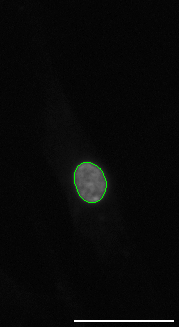
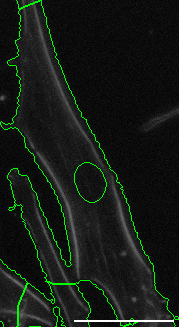
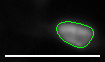
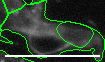
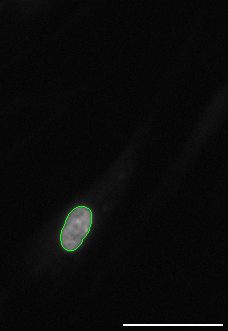
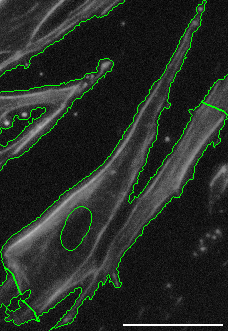
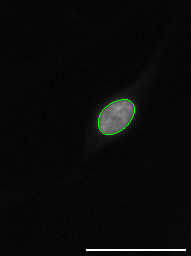
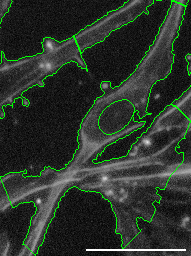
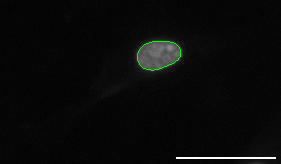
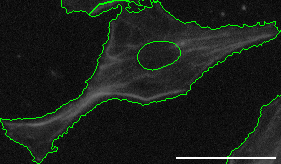

In [ ]:
# Filter cosmicqc_df
failed_ecod_df = cosmicqc_df[
    (cosmicqc_df["ECOD_flag"] == 1)
    & (cosmicqc_df["Metadata_QC_status"] != "failed")
    & (cosmicqc_df["Metadata_Well"].isin(["C09", "E09", "C06", "E06"]))
]

failed_ecod_df_cdf = CytoDataFrame(
    data=failed_ecod_df,
    data_context_dir=Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/1.preprocessing_data/Corrected_Images/localhost230405150001"
    ),
    data_outline_context_dir=Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/2.cellprofiler_processing/cp_output/localhost230405150001/outlines"
    ),
    image_adjustment=mild_histogram_equalization,
    display_options={
        "brightness": 1,
        "um_per_pixel": 1,
        "center_dot": False,
        "scale_bar": {
            "length_um": 100,
            "location": "lower right",
            "color": (255, 255, 255),
            "thickness_px": 2,
            "margin_px": 5,
        },
    },
)[
    [
        "ECOD_flag",
        "FileName_Hoechst",
        "FileName_Actin",
        "Metadata_Well",
        "Metadata_Site",
    ]
]

failed_ecod_df_cdf.sample(n=5, random_state=42)


,ECOD_flag,FileName_Hoechst,FileName_Actin,Metadata_Well,Metadata_Site
7114,0,,,C06,f02
7403,0,,,C06,f14
7092,0,,,C06,f02
8626,0,,,C09,f10
7116,0,,,C06,f02

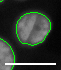
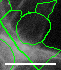
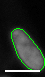
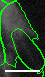
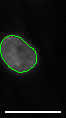
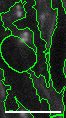
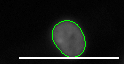
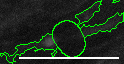
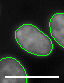
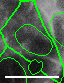

In [ ]:
# Filter cosmicqc_df
failed_cosmicqc_df = cosmicqc_df[
    (cosmicqc_df["ECOD_flag"] == 0)
    & (cosmicqc_df["Metadata_QC_status"] == "failed")
    & (cosmicqc_df["Metadata_Well"].isin(["C09", "E09", "C06", "E06"]))
]

failed_cosmicqc_df_cdf = CytoDataFrame(
    data=failed_cosmicqc_df,
    data_context_dir=Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/1.preprocessing_data/Corrected_Images/localhost230405150001"
    ),
    data_outline_context_dir=Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/2.cellprofiler_processing/cp_output/localhost230405150001/outlines"
    ),
    image_adjustment=mild_histogram_equalization,
    display_options={
        "brightness": 1,
        "um_per_pixel": 1,
        "center_dot": False,
        "scale_bar": {
            "length_um": 100,
            "location": "lower right",
            "color": (255, 255, 255),
            "thickness_px": 2,
            "margin_px": 5,
        },
    },
)[
    [
        "ECOD_flag",
        "FileName_Hoechst",
        "FileName_Actin",
        "Metadata_Well",
        "Metadata_Site",
    ]
]

failed_cosmicqc_df_cdf.sample(n=5, random_state=42)


In [ ]:
# Update QC_combined_group to have more descriptive labels
cosmicqc_df["QC_combined_group"] = cosmicqc_df["QC_combined_group"].map(
    {
        "not_flagged": "Did not fail QC",
        "ECOD_only": "PyOD ECOD only",
        "coSMicQC_only": "coSMicQC only",
        "both_flagged": "Failed both QC methods",
    }
)

# Update treatment-cell type IDs for plain English formatting
cosmicqc_df["Metadata_Treatment_CellType_ID"] = cosmicqc_df[
    "Metadata_Treatment_CellType_ID"
].replace(
    {
        "control_diseased": "DMSO-control diseased",
        "treatment1_diseased": "Treatment 1 diseased",
        "treatment2_diseased": "Treatment 2 diseased",
        "control_healthy": "DMSO-control healthy",
        "treatment1_healthy": "Treatment 1 healthy",
        "treatment2_healthy": "Treatment 2 healthy",
    }
)

print(
    "Unique Treatment_CellType_IDs:",
    cosmicqc_df["Metadata_Treatment_CellType_ID"].unique(),
)


Unique Treatment_CellType_IDs: ['DMSO-control diseased' 'Treatment 2 diseased' 'Treatment 1 diseased'
 'DMSO-control healthy' 'Treatment 2 healthy' 'Treatment 1 healthy']


In [ ]:
order = {
    "DMSO-control": 0,
    "Treatment 1": 1,
    "Treatment 2": 2,
}

facet_levels = sorted(
    cosmicqc_df["Metadata_Treatment_CellType_ID"].dropna().unique(),
    key=lambda x: (
        next((v for k, v in order.items() if str(x).startswith(k)), 999),
        str(x),
    ),
)

print(facet_levels)  # <-- check this is in the order you want

cosmicqc_df = cosmicqc_df.assign(
    Metadata_Treatment_CellType_ID=pd.Categorical(
        cosmicqc_df["Metadata_Treatment_CellType_ID"],
        categories=facet_levels,
        ordered=True,
    )
)


['DMSO-control diseased', 'DMSO-control healthy', 'Treatment 1 diseased', 'Treatment 1 healthy', 'Treatment 2 diseased', 'Treatment 2 healthy']


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 15 x 8 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/ECOD_vs_cosmicqc_umap_retransplantation_plate.png


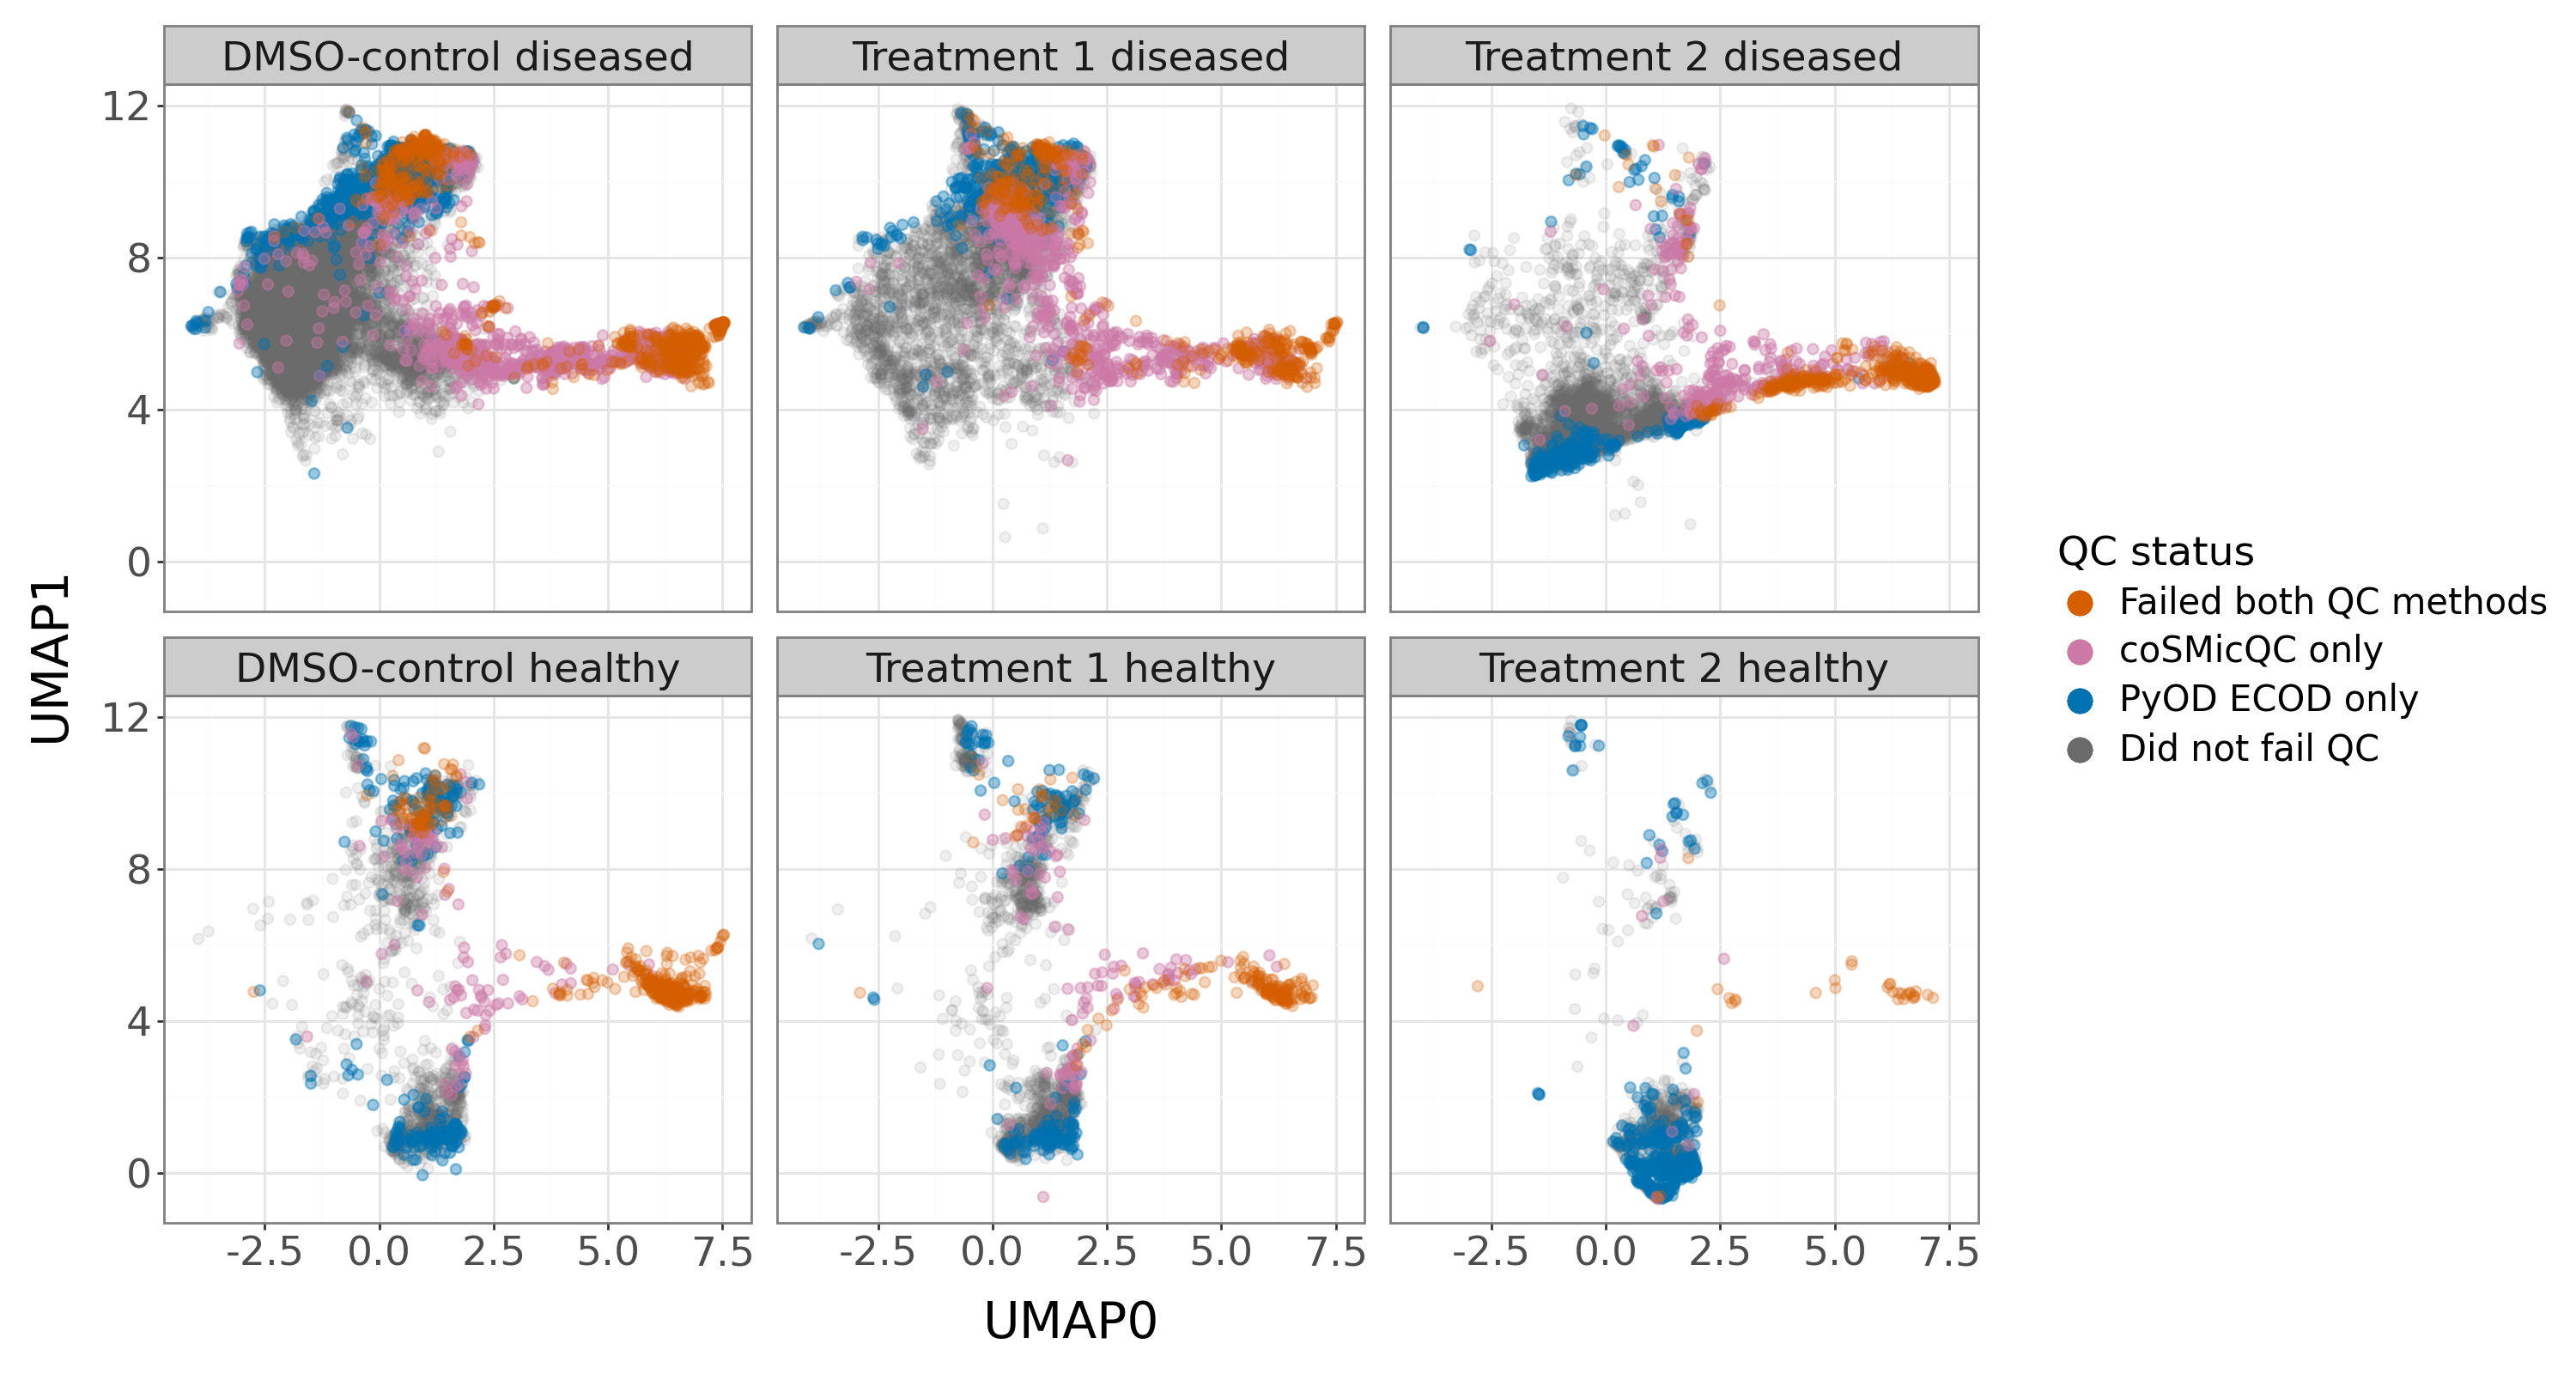

In [ ]:
# Set the figure size
height = 8
width = 15
set_option("figure_size", (width, height))

# Plot UMAP of non-QC profiles labelled with QC status and
# faceted by treatment and cell type
p = (
    ggplot(
        cosmicqc_df,
        aes(x="UMAP0", y="UMAP1", color="QC_combined_group"),
    )
    + labs(
        color="QC status",
    )
    + geom_point(
        data=cosmicqc_df.query("QC_combined_group == 'Did not fail QC'"),
        mapping=aes(x="UMAP0", y="UMAP1", color="QC_combined_group"),
        alpha=0.1,
        size=2,
    )
    + geom_point(
        data=cosmicqc_df.query("QC_combined_group == 'PyOD ECOD only'"),
        mapping=aes(x="UMAP0", y="UMAP1", color="QC_combined_group"),
        alpha=0.4,
        size=2,
    )
    + geom_point(
        data=cosmicqc_df.query("QC_combined_group == 'coSMicQC only'"),
        mapping=aes(x="UMAP0", y="UMAP1", color="QC_combined_group"),
        alpha=0.4,
        size=2,
    )
    + geom_point(
        data=cosmicqc_df.query("QC_combined_group == 'Failed both QC methods'"),
        mapping=aes(x="UMAP0", y="UMAP1", color="QC_combined_group"),
        alpha=0.25,
        size=2,
    )
    + facet_wrap(
        "Metadata_Treatment_CellType_ID",
        ncol=3,
        scales="fixed",
        dir="v"
    )
    + theme_bw()
    + theme(
        axis_title=element_text(size=21),
        axis_text=element_text(size=17),
        legend_title=element_text(size=17),
        legend_text=element_text(size=15),
        legend_position="right",
        strip_text=element_text(size=17),  # Adjust facet label size
    )
    + scale_color_manual(
        values={
            "Did not fail QC": "#6B6B6B",  # grey (background population)
            "PyOD ECOD only": "#0072B2",  # blue
            "coSMicQC only": "#CC79A7",  # purple
            "Failed both QC methods": "#D55E00",  # orange
        }
    )
    + guides(
        color=guide_legend(
            override_aes={
                "alpha": 1,
                "size": 5,
            }
        ),
        alpha=False,
    )
)
# Save the plot
p.save(
    figure_dir / "ECOD_vs_cosmicqc_umap_retransplantation_plate.png",
    dpi=600,
    width=width,
    height=height,
)

p.show()


In [ ]:
# Compare QC failure rates
group_col = "Metadata_Treatment_CellType_ID"

cosmicqc_df["coSMicQC_flag"] = (cosmicqc_df["Metadata_QC_status"] != "passed").astype(
    int
)

qc_rates = (
    cosmicqc_df.groupby(group_col)
    .agg(
        ECOD_fail_rate=("ECOD_flag", "mean"),
        coSMicQC_fail_rate=("coSMicQC_flag", "mean"),
        n_cells=("ECOD_flag", "size"),
    )
    .reset_index()
)

# convert to percent
qc_rates["ECOD_fail_rate"] *= 100
qc_rates["coSMicQC_fail_rate"] *= 100


/tmp/ipykernel_3521851/18791066.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [ ]:
qc_rates.sort_values("ECOD_fail_rate", ascending=False)


,Metadata_Treatment_CellType_ID,ECOD_fail_rate,coSMicQC_fail_rate,n_cells
5,Treatment 2 healthy,42.148199,2.991162,1471
1,DMSO-control healthy,34.359538,24.903793,1819
3,Treatment 1 healthy,22.034851,16.469927,1779
4,Treatment 2 diseased,19.626979,20.949902,4611
2,Treatment 1 diseased,18.198307,23.659815,4962
0,DMSO-control diseased,13.782651,18.400642,11217


In [ ]:
# Filter out treatment2_healthy
filtered_qc_rates = qc_rates[
    qc_rates["Metadata_Treatment_CellType_ID"] != "treatment2_healthy"
].copy()

# Compute overall fail rates per method
ecod_fail_rate = filtered_qc_rates["ECOD_fail_rate"].mean()
cosmicqc_fail_rate = filtered_qc_rates["coSMicQC_fail_rate"].mean()

print("ECOD mean fail rate:", ecod_fail_rate)
print("coSMicQC mean fail rate:", cosmicqc_fail_rate)

# -----------------------------
# CONSISTENCY ACROSS CONDITIONS
# -----------------------------

# Standard deviation (spread across condition/treatment IDs)
ecod_std = filtered_qc_rates["ECOD_fail_rate"].std()
cosmicqc_std = filtered_qc_rates["coSMicQC_fail_rate"].std()

print("ECOD variability (std):", ecod_std)
print("coSMicQC variability (std):", cosmicqc_std)

# Median absolute deviation (robust variability)
ecod_mad = (
    (filtered_qc_rates["ECOD_fail_rate"] - filtered_qc_rates["ECOD_fail_rate"].median())
    .abs()
    .median()
)

cosmicqc_mad = (
    (
        filtered_qc_rates["coSMicQC_fail_rate"]
        - filtered_qc_rates["coSMicQC_fail_rate"].median()
    )
    .abs()
    .median()
)

print("ECOD MAD:", ecod_mad)
print("coSMicQC MAD:", cosmicqc_mad)

# -----------------------------
# METHOD DISAGREEMENT PER CONDITION
# -----------------------------

filtered_qc_rates["method_abs_diff"] = (
    filtered_qc_rates["ECOD_fail_rate"] - filtered_qc_rates["coSMicQC_fail_rate"]
).abs()

mean_method_diff = filtered_qc_rates["method_abs_diff"].mean()

print("Mean absolute ECOD vs coSMicQC difference:", mean_method_diff)


ECOD mean fail rate: 25.025087530417057
coSMicQC mean fail rate: 17.89587359563304
ECOD variability (std): 10.875764722381932
coSMicQC variability (std): 7.951095205052339
ECOD MAD: 4.840435768120037
coSMicQC MAD: 3.594943832825937
Mean absolute ECOD vs coSMicQC difference: 10.930021085006365


In [ ]:
# Standard deviation (spread across condition/treatment IDs)
ecod_std = qc_rates["ECOD_fail_rate"].std()
cosmicqc_std = qc_rates["coSMicQC_fail_rate"].std()

print("ECOD variability (std):", ecod_std)
print("coSMicQC variability (std):", cosmicqc_std)

# Median absolute deviation (robust variability)
ecod_mad = (
    (qc_rates["ECOD_fail_rate"] - qc_rates["ECOD_fail_rate"].median()).abs().median()
)

cosmicqc_mad = (
    (qc_rates["coSMicQC_fail_rate"] - qc_rates["coSMicQC_fail_rate"].median())
    .abs()
    .median()
)

print("ECOD MAD:", ecod_mad)
print("coSMicQC MAD:", cosmicqc_mad)

# -----------------------------
# METHOD DISAGREEMENT PER CONDITION
# -----------------------------

qc_rates["method_abs_diff"] = (
    qc_rates["ECOD_fail_rate"] - qc_rates["coSMicQC_fail_rate"]
).abs()

mean_method_diff = qc_rates["method_abs_diff"].mean()

print("Mean absolute ECOD vs coSMicQC difference:", mean_method_diff)


ECOD variability (std): 10.875764722381932
coSMicQC variability (std): 7.951095205052339
ECOD MAD: 4.840435768120037
coSMicQC MAD: 3.594943832825937
Mean absolute ECOD vs coSMicQC difference: 10.930021085006365


## Load in no QC feature-selected profile for retransplantation plate for pairwise comparison

In [ ]:
# Load in feature selected QC profile for retransplanation plate (no_QC_fs_df)
no_QC_fs_df = pd.read_parquet(
    Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost230405150001_sc_feature_selected_no_QC.parquet"
    )
)

# Based on coSMicQC_df, annotate the no_QC_fs_df with QC status from coSMicQC and ECOD
no_QC_fs_df = no_QC_fs_df.copy()
join_cols = [
    "Metadata_Plate",
    "Metadata_Well",
    "Metadata_Site",
    "Metadata_Nuclei_Number_Object_Number",
]

# Add coSMicQC annotations
no_QC_fs_df = no_QC_fs_df.merge(
    cosmicqc_df[[*join_cols, "Metadata_QC_status", "coSMicQC_flag"]].drop_duplicates(),
    on=join_cols,
    how="left",
)

# Add ECOD annotations
no_QC_fs_df = no_QC_fs_df.merge(
    no_QC_df[[*join_cols, "ECOD_flag"]].drop_duplicates(),
    on=join_cols,
    how="left",
)

no_QC_fs_df.head()


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_03_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_01_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_03_256,Nuclei_Texture_SumVariance_ER_3_01_256,Nuclei_Texture_SumVariance_Hoechst_3_01_256,Nuclei_Texture_SumVariance_Mitochondria_3_01_256,Nuclei_Texture_SumVariance_PM_3_01_256,Metadata_QC_status,coSMicQC_flag,ECOD_flag
0,B,2,9,failing,rejected,DMSO,221.046761,137.115493,246.602800,109.285755,...,0.906721,0.418794,0.385735,-0.133843,-0.363257,-0.262538,-0.309825,passed,0,0
1,B,2,9,failing,rejected,DMSO,690.596142,183.067828,716.170091,177.132195,...,-0.068447,0.437270,0.335719,-0.216157,-0.371891,2.526579,-0.183663,passed,0,0
2,B,2,9,failing,rejected,DMSO,626.561490,206.923698,623.943740,199.906440,...,0.454668,0.791982,0.541460,-0.121337,-0.395564,-0.234732,-0.316161,passed,0,0
3,B,2,9,failing,rejected,DMSO,559.448583,220.688160,528.646623,196.955552,...,0.206056,0.707142,0.398355,-0.164322,-0.366784,-0.150974,-0.212531,passed,0,0
4,B,2,9,failing,rejected,DMSO,909.019946,247.694340,897.965996,253.621836,...,-0.821989,0.978198,0.974789,-0.433306,-0.391546,0.044598,-0.349236,passed,0,0


## Separate in groups

In [ ]:
# Extract feature columns
feature_cols = [
    col
    for col in no_QC_fs_df.columns
    if not col.startswith(
        (
            "Metadata_",
            "FileName",
            "ECOD_flag",
            "coSMicQC_flag",
        )
    )
]

# Create feature matrices for comparisons
failed_cosmicqc_features = no_QC_fs_df.loc[
    no_QC_fs_df["Metadata_QC_status"] == "failed",
    feature_cols,
]

passed_cosmicqc_features = no_QC_fs_df.loc[
    no_QC_fs_df["Metadata_QC_status"] == "passed",
    feature_cols,
]

failed_ecod_features = no_QC_fs_df.loc[
    no_QC_fs_df["ECOD_flag"] == 1,
    feature_cols,
]

passed_ecod_features = no_QC_fs_df.loc[
    no_QC_fs_df["ECOD_flag"] == 0,
    feature_cols,
]
# print counts
print("Original counts -")
print("cosmicqc failed:", len(failed_cosmicqc_features))
print("cosmicqc passed:", len(passed_cosmicqc_features))
print("ecod failed:", len(failed_ecod_features))
print("ecod passed:", len(passed_ecod_features))


Original counts -
cosmicqc failed: 4994
cosmicqc passed: 20865
ecod failed: 4991
ecod passed: 20868


In [ ]:
rng = np.random.default_rng(0)

# COSMICQC: match passed size to failed size
n_cosmic_fail = len(failed_cosmicqc_features)

passed_cosmicqc_features = passed_cosmicqc_features.iloc[
    rng.choice(len(passed_cosmicqc_features), n_cosmic_fail, replace=False)
]

# ECOD: match passed size to failed size
n_ecod_fail = len(failed_ecod_features)

passed_ecod_features = passed_ecod_features.iloc[
    rng.choice(len(passed_ecod_features), n_ecod_fail, replace=False)
]

# print counts
print("Sampled data -")
print("cosmicqc failed:", len(failed_cosmicqc_features))
print("cosmicqc passed (matched):", len(passed_cosmicqc_features))

print("ecod failed:", len(failed_ecod_features))
print("ecod passed (matched):", len(passed_ecod_features))


Sampled data -
cosmicqc failed: 4994
cosmicqc passed (matched): 4994
ecod failed: 4991
ecod passed (matched): 4991


In [ ]:
# Call dataframe plot dataframe for saving correlations
plot_path = cache_dir / "retranplant_plate_pairwise_corr_cosmic_ecod.parquet"

# -----------------------------
# SKIP IF ALREADY COMPUTED
# -----------------------------
if plot_path.exists():
    plot_df = pd.read_parquet(plot_path)
    print("Loaded existing plot_df:", plot_df.shape)

else:
    # -----------------------------
    # WITHIN-GROUP PAIRWISE CORRELATIONS
    # -----------------------------

    failed_cosmicqc_corr = np.corrcoef(failed_cosmicqc_features.values)
    passed_cosmicqc_corr = np.corrcoef(passed_cosmicqc_features.values)

    failed_ecod_corr = np.corrcoef(failed_ecod_features.values)
    passed_ecod_corr = np.corrcoef(passed_ecod_features.values)

    failed_cosmicqc_corr_values = failed_cosmicqc_corr[
        np.triu_indices_from(failed_cosmicqc_corr, k=1)
    ]

    passed_cosmicqc_corr_values = passed_cosmicqc_corr[
        np.triu_indices_from(passed_cosmicqc_corr, k=1)
    ]

    failed_ecod_corr_values = failed_ecod_corr[
        np.triu_indices_from(failed_ecod_corr, k=1)
    ]

    passed_ecod_corr_values = passed_ecod_corr[
        np.triu_indices_from(passed_ecod_corr, k=1)
    ]


    # -----------------------------
    # BETWEEN-GROUP PAIRWISE CORRELATIONS (FAST VECTORISED)
    # -----------------------------

    passed_failed_cosmicqc_corr = np.corrcoef(
        passed_cosmicqc_features.values,
        failed_cosmicqc_features.values
    )[:len(passed_cosmicqc_features), len(passed_cosmicqc_features):]

    passed_failed_ecod_corr = np.corrcoef(
        passed_ecod_features.values,
        failed_ecod_features.values
    )[:len(passed_ecod_features), len(passed_ecod_features):]


    passed_failed_cosmicqc_corr_values = passed_failed_cosmicqc_corr.ravel()
    passed_failed_ecod_corr_values = passed_failed_ecod_corr.ravel()


    # -----------------------------
    # Create plot dataframe and save
    # -----------------------------

    plot_df = pd.concat(
        [
            pd.DataFrame({
                "correlation": failed_cosmicqc_corr_values,
                "group": "Failed coSMicQC vs Failed coSMicQC",
            }),
            pd.DataFrame({
                "correlation": passed_cosmicqc_corr_values,
                "group": "Passed coSMicQC vs Passed coSMicQC",
            }),
            pd.DataFrame({
                "correlation": passed_failed_cosmicqc_corr_values,
                "group": "Passed coSMicQC vs Failed coSMicQC",
            }),
            pd.DataFrame({
                "correlation": failed_ecod_corr_values,
                "group": "Failed ECOD vs Failed ECOD",
            }),
            pd.DataFrame({
                "correlation": passed_ecod_corr_values,
                "group": "Passed ECOD vs Passed ECOD",
            }),
            pd.DataFrame({
                "correlation": passed_failed_ecod_corr_values,
                "group": "Passed ECOD vs Failed ECOD",
            }),
        ],
        ignore_index=True,
    )

    plot_df = (
        plot_df
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    plot_df.to_parquet(plot_path, index=False)
    print("Saved plot_df:", plot_df.shape)


Loaded existing plot_df: (99690249, 2)


In [ ]:
# Print summary statistics on FULL dataset
summary_df = (
    plot_df.groupby("group")["correlation"].agg(["mean", "median", "std"]).round(3)
)
print(summary_df)


# Apply the new comparison labels for plotting
plot_df["qc_comparison"] = plot_df["group"].apply(classify_comparison)

# Create facet label (ECOD vs coSMicQC)
plot_df["comparison"] = plot_df["group"].apply(
    lambda x: "ECOD" if "ECOD" in x else "coSMicQC"
)


                                     mean  median    std
group                                                   
Failed ECOD vs Failed ECOD          0.052   0.021  0.298
Failed coSMicQC vs Failed coSMicQC  0.165   0.158  0.225
Passed ECOD vs Failed ECOD         -0.025  -0.051  0.205
Passed ECOD vs Passed ECOD          0.013   0.001  0.174
Passed coSMicQC vs Failed coSMicQC -0.059  -0.077  0.166
Passed coSMicQC vs Passed coSMicQC  0.023   0.014  0.191


Using 300,000 correlations for plotting (from 99,690,249 total correlations).


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 13 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/ECOD_vs_cosmicqc_correlation_comparisons.png


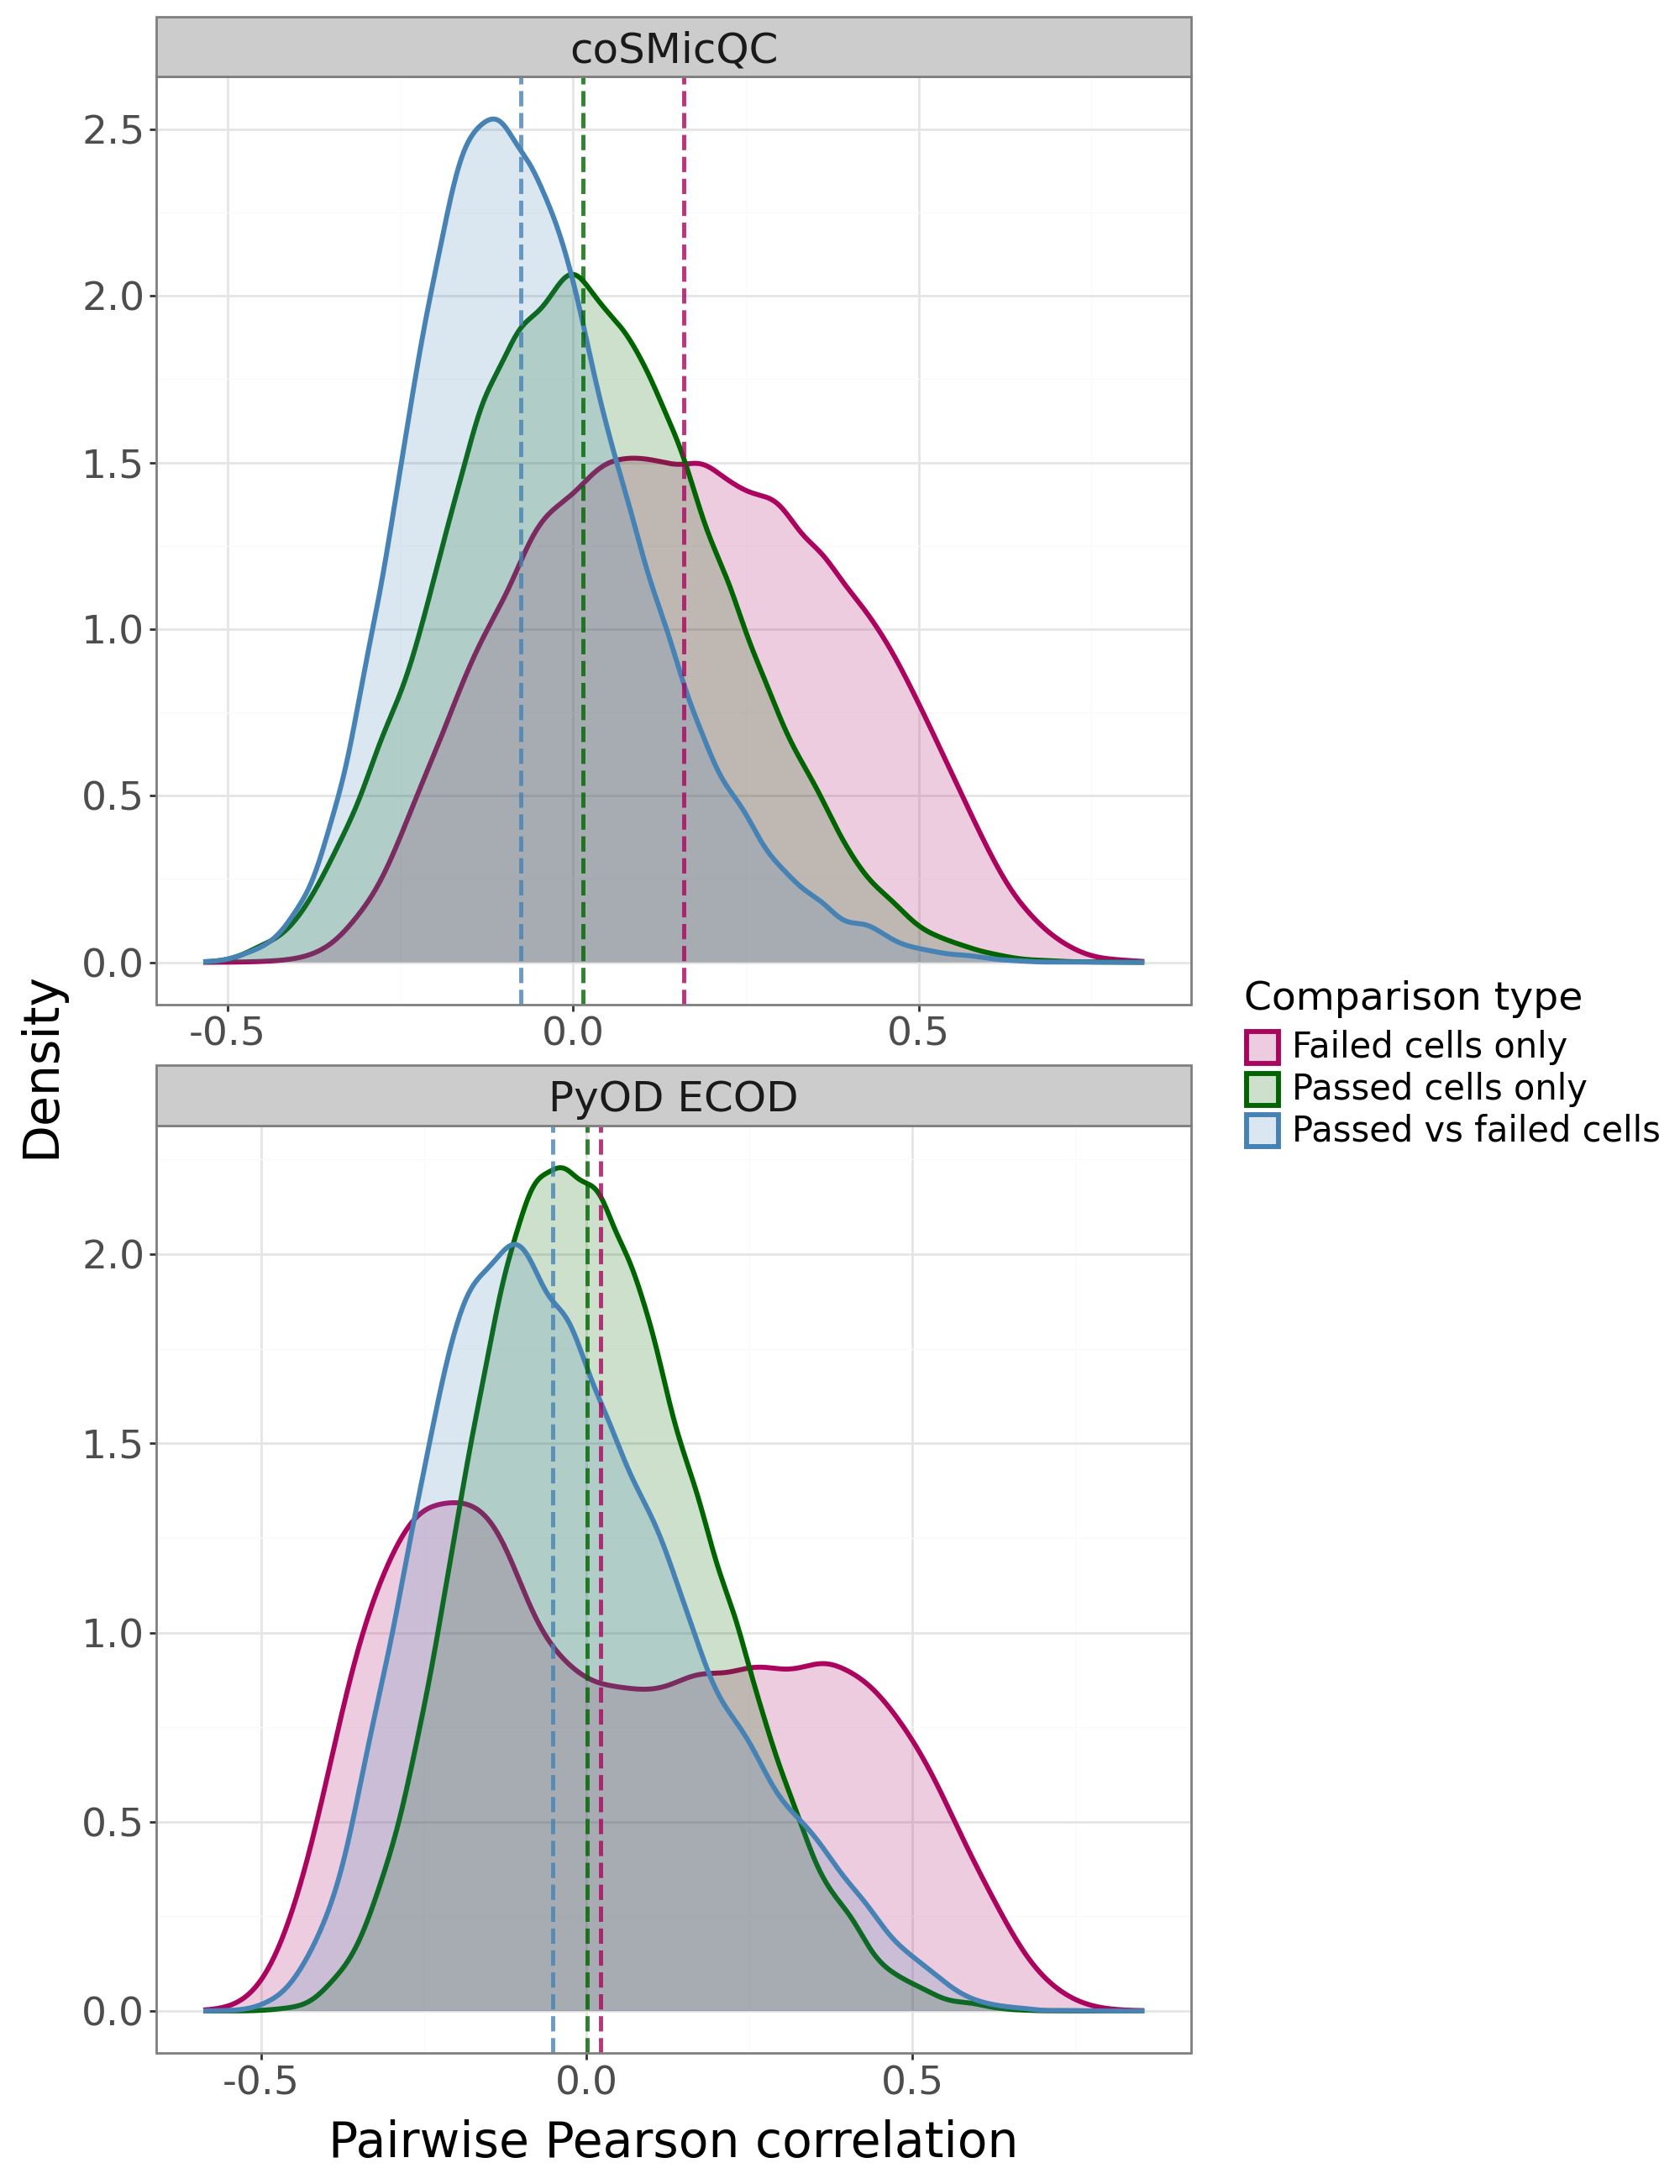

In [ ]:
# -----------------------------
# Downsample for plotting only
# -----------------------------
# Use a large, reproducible subsample per group for KDE estimation.
# Summary statistics above are still calculated on the full dataset.

plot_df_plot = (
    plot_df.groupby("group", group_keys=False)
    .sample(
        n=min(
            50_000,
            plot_df.groupby("group").size().min(),
        ),
        random_state=0,
    )
    .reset_index(drop=True)
)

print(
    f"Using {len(plot_df_plot):,} correlations for plotting "
    f"(from {len(plot_df):,} total correlations)."
)

# Set the figure size
height = 13
width = 10
set_option("figure_size", (width, height))

# median values for vertical lines
med_df = (
    plot_df_plot.groupby(
        ["group", "comparison", "qc_comparison"]
    )["correlation"]
    .median()
    .reset_index()
)

# Flip facets
plot_df_plot["comparison"] = pd.Categorical(
    plot_df_plot["comparison"],
    categories=["coSMicQC", "ECOD"],
    ordered=True,
)

med_df["comparison"] = pd.Categorical(
    med_df["comparison"],
    categories=["coSMicQC", "ECOD"],
    ordered=True,
)

# Plot
p = (
    ggplot(
        plot_df_plot,
        aes(
            x="correlation",
            color="qc_comparison",
            fill="qc_comparison",
        ),
    )
    + geom_density(
        size=1.2,
        alpha=0.20,
    )
    + geom_vline(
        med_df,
        aes(
            xintercept="correlation",
            color="qc_comparison",
        ),
        linetype="dashed",
        size=1.0,
        alpha=0.8,
        show_legend=False,
    )
    + facet_wrap(
        "~comparison",
        scales="free",
        ncol=1,
        labeller=lambda x: "PyOD ECOD" if x == "ECOD" else x,
        dir='v'
    )
    + scale_color_manual(
        values={
            "Failed cells only": "#AA045F",  # magenta
            "Passed cells only": "#006400",  # dark green
            "Passed vs failed cells": "#4682B4",  # steel blue
        }
    )
    + scale_fill_manual(
        values={
            "Failed cells only": "#AA045F",  # magenta
            "Passed cells only": "#006400",  # dark green
            "Passed vs failed cells": "#4682B4",  # steel blue
        }
    )
    + labs(
        x="Pairwise Pearson correlation",
        y="Density",
        color="Comparison type",
        fill="Comparison type",
    )
    + theme_bw()
    + theme(
        legend_position="right",
        axis_title=element_text(size=21),
        axis_text=element_text(size=17),
        strip_text=element_text(size=18),
        legend_title=element_text(size=17),
        legend_text=element_text(size=15),
    )
)

# Save the plot
p.save(
    figure_dir / "ECOD_vs_cosmicqc_correlation_comparisons.png",
    dpi=600,
    width=width,
    height=height,
)

p.show()


In [ ]:
# -----------------------------
# Calculate effect sizes from plot_df
# -----------------------------

d_cosmicqc = compute_cohens_d(
    plot_df.loc[
        plot_df["group"] == "Failed coSMicQC vs Failed coSMicQC",
        "correlation",
    ].to_numpy(),
    plot_df.loc[
        plot_df["group"] == "Passed coSMicQC vs Passed coSMicQC",
        "correlation",
    ].to_numpy(),
)

d_ecod = compute_cohens_d(
    plot_df.loc[
        plot_df["group"] == "Failed ECOD vs Failed ECOD",
        "correlation",
    ].to_numpy(),
    plot_df.loc[
        plot_df["group"] == "Passed ECOD vs Passed ECOD",
        "correlation",
    ].to_numpy(),
)

# -----------------------------
# Summary table
# -----------------------------
effect_size_df = pd.DataFrame(
    {
        "Method": ["coSMicQC", "ECOD"],
        "Comparison": ["Failed vs Passed", "Failed vs Passed"],
        "Cohens_d": [d_cosmicqc, d_ecod],
    }
)

print("Effect sizes:")
display(effect_size_df.round(3))

# -----------------------------
# Comparison
# -----------------------------
effect_size_difference = d_cosmicqc - d_ecod

print("\nComparison:")
print(f"coSMicQC Cohen's d: {d_cosmicqc:.3f}")
print(f"ECOD Cohen's d:     {d_ecod:.3f}")
print(f"Difference:         {effect_size_difference:.3f}")

if effect_size_difference > 0:
    print(
        f"\ncoSMicQC has the larger effect size by "
        f"{effect_size_difference:.3f} Cohen's d units."
    )
elif effect_size_difference < 0:
    print(
        f"\nECOD has the larger effect size by "
        f"{abs(effect_size_difference):.3f} Cohen's d units."
    )
else:
    print("\nBoth methods have identical effect sizes.")


Effect sizes:


,Method,Comparison,Cohens_d
0,coSMicQC,Failed vs Passed,0.680
1,ECOD,Failed vs Passed,0.163



Comparison:
coSMicQC Cohen's d: 0.680
ECOD Cohen's d:     0.163
Difference:         0.518

coSMicQC has the larger effect size by 0.518 Cohen's d units.


In [ ]:
effect_size_ratio = d_cosmicqc / d_ecod

print(
    f"coSMicQC's effect size is {effect_size_ratio:.1f}× larger than ECOD's "
    f"(Cohen's d = {d_cosmicqc:.3f} vs {d_ecod:.3f})."
)


coSMicQC's effect size is 4.2× larger than ECOD's (Cohen's d = 0.680 vs 0.163).


In [ ]:
# -----------------------------
# Calculate effect size from plot_df
# -----------------------------

d_pvf_both_methods = compute_cohens_d(
    plot_df.loc[
        plot_df["group"] == "Passed coSMicQC vs Failed coSMicQC",
        "correlation",
    ].to_numpy(),
    plot_df.loc[
        plot_df["group"] == "Passed ECOD vs Failed ECOD",
        "correlation",
    ].to_numpy(),
)

# -----------------------------
# Display result
# -----------------------------

effect_size_df = pd.DataFrame(
    {
        "Comparison": ["Passed coSMicQC vs Failed coSMicQC compared to Passed ECOD vs Failed ECOD"],
        "Cohens_d": [d_pvf_both_methods],
    }
)

display(effect_size_df.round(3))


,Comparison,Cohens_d
0,Passed coSMicQC vs Failed coSMicQC compared to...,-0.182


In [ ]:
# -----------------------------
# Build shared cell pool for permutation testing
# -----------------------------
is_fail_cosmicqc_full = (no_QC_fs_df["Metadata_QC_status"] == "failed").to_numpy()
is_fail_ecod_full = (no_QC_fs_df["ECOD_flag"] == 1).to_numpy()

rng = np.random.default_rng(0)
failed_either = is_fail_cosmicqc_full | is_fail_ecod_full
passed_both = (~is_fail_cosmicqc_full) & (~is_fail_ecod_full)
failed_idx = np.where(failed_either)[0]
passed_idx = np.where(passed_both)[0]

n_passed_sample = min(len(passed_idx), len(failed_idx))
sampled_passed_idx = rng.choice(passed_idx, size=n_passed_sample, replace=False)

pool_idx = np.sort(np.concatenate([failed_idx, sampled_passed_idx]))
pool_df = no_QC_fs_df.iloc[pool_idx].reset_index(drop=True)

pool_X = pool_df[feature_cols]
pool_X_clean = pool_X.loc[:, ~pool_X.isna().any()]

corr_matrix_path = cache_dir / "pooled_population_corr_matrix.npy"

if corr_matrix_path.exists():
    corr_matrix = np.load(corr_matrix_path)
else:
    corr_matrix = np.corrcoef(pool_X_clean.values)
    np.save(corr_matrix_path, corr_matrix)

is_fail_cosmicqc = (pool_df["Metadata_QC_status"] == "failed").to_numpy()
is_fail_ecod = (pool_df["ECOD_flag"] == 1).to_numpy()

print(
    f"Pool size: {len(pool_df)} | coSMicQC fails: {is_fail_cosmicqc.sum()} | ECOD fails: {is_fail_ecod.sum()}"
)

# -----------------------------
# Precompute shared matrices ONCE, reuse across all three tests
# -----------------------------
t0 = time.time()
stats = prep_corr_stats(corr_matrix)
print(f"prep_corr_stats: {time.time() - t0:.1f}s")

t0 = time.time()
result_cosmicqc = permutation_test_within_method_fast(
    stats, is_fail_cosmicqc, n_permutations=10000, seed=0
)
result_ecod = permutation_test_within_method_fast(
    stats, is_fail_ecod, n_permutations=10000, seed=0
)
result_between = permutation_test_between_methods_fast(
    stats, is_fail_cosmicqc, is_fail_ecod, n_permutations=10000, seed=0
)
print(f"All three permutation tests: {time.time() - t0:.1f}s")

print(
    "\ncoSMicQC — d_observed:",
    round(result_cosmicqc["d_observed"], 3),
    "| p =",
    round(result_cosmicqc["p_value"], 4),
)
print(
    "ECOD     — d_observed:",
    round(result_ecod["d_observed"], 3),
    "| p =",
    round(result_ecod["p_value"], 4),
)
print(
    "Between-method diff:",
    round(result_between["diff_observed"], 3),
    "| p =",
    round(result_between["p_value"], 4),
)


Pool size: 15296 | coSMicQC fails: 4994 | ECOD fails: 4991
prep_corr_stats: 0.6s
All three permutation tests: 78.1s

coSMicQC — d_observed: 0.692 | p = 0.0001
ECOD     — d_observed: 0.23 | p = 0.0001
Between-method diff: 0.463 | p = 0.0


In [ ]:
result_cross_group = permutation_test_cross_group_between_methods_fast(
    stats,
    is_fail_cosmicqc,
    is_fail_ecod,
    n_permutations=10000,
    seed=0,
    batch_size=1000,
)

print("Cells pooled:", len(is_fail_cosmicqc))
print("coSMicQC failures:", is_fail_cosmicqc.sum())
print("ECOD failures:", is_fail_ecod.sum())

print(
    "Cross-group correlation difference:",
    round(result_cross_group["d_observed"], 3),
    "| p =",
    round(result_cross_group["p_value"], 4),
)


Cells pooled: 15296
coSMicQC failures: 4994
ECOD failures: 4991
Cross-group correlation difference: -0.208 | p = 0.0001
